### HCML Project code group X
Sam Busstra - 2349515  
Kasper Klink -  
Theresa  
Jim

In [1]:
# installs
!pip install folktables
from folktables import ACSDataSource, ACSIncome
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Part 1: Exporatory data analysis
### Loading the data

In [2]:
# data loading

data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=["CA", "NY", "TX"], download=True) # only take 3 states since datasize will get too big otherwise

feature_names = ACSIncome.features
df = acs_data[feature_names].copy()
df['label'] = (acs_data['PINCP'] > 50000).astype(int)

# Recode SEX to 0/1 already
df['SEX'] = df['SEX'].map({1: 0, 2: 1})  # 0=Male, 1=Female

### Descriptive statistics

In [3]:
print(df.shape)
print(df.dtypes)
print(df.describe())

(843884, 11)
AGEP       int64
COW      float64
SCHL     float64
MAR        int64
OCCP     float64
POBP       int64
RELP       int64
WKHP     float64
SEX        int64
RAC1P      int64
label      int64
dtype: object
                AGEP            COW           SCHL            MAR  \
count  843884.000000  496001.000000  818451.000000  843884.000000   
mean       40.435203       2.169490      15.983083       3.021073   
std        23.363167       1.946451       5.878467       1.867496   
min         0.000000       1.000000       1.000000       1.000000   
25%        21.000000       1.000000      14.000000       1.000000   
50%        40.000000       1.000000      18.000000       3.000000   
75%        59.000000       3.000000      21.000000       5.000000   
max        95.000000       9.000000      24.000000       5.000000   

                OCCP           POBP           RELP           WKHP  \
count  496001.000000  843884.000000  843884.000000  437311.000000   
mean     4141.377066      

### Important distributions

In [4]:

# Class imbalance in target
df['label'].value_counts(normalize=True)

# Distribution of protected attributes
df['SEX'].value_counts()
df['RAC1P'].value_counts()

# Base rates
df.groupby('SEX')['label'].mean()
df.groupby('RAC1P')['label'].mean()

# Intersectional base rates
df.groupby(['SEX', 'RAC1P'])['label'].mean().unstack()

RAC1P,1,2,3,4,5,6,7,8,9
SEX,,,,,,,,,
0,0.320121,0.177532,0.207556,0.130435,0.137019,0.319976,0.215789,0.136191,0.178239
1,0.192491,0.158275,0.132903,0.200000,0.088861,0.227896,0.124823,0.066673,0.134962


### Visualizing data

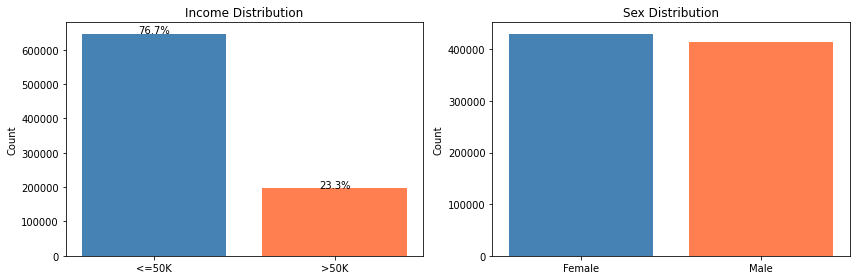

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
axes[0].bar(['<=50K', '>50K'], df['label'].value_counts().sort_index(), color=['steelblue', 'coral'])
axes[0].set_title('Income Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['label'].value_counts().sort_index()):
    axes[0].text(i, v + 100, f'{v/len(df)*100:.1f}%', ha='center')

# SEX distribution
sex_labels = {0: 'Male', 1: 'Female'}
sex_counts = df['SEX'].map(sex_labels).value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=['steelblue', 'coral'])
axes[1].set_title('Sex Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

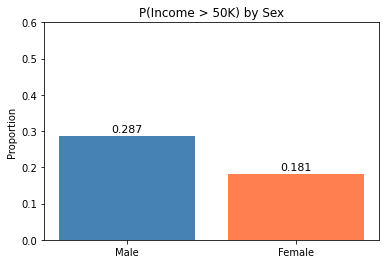

In [6]:
# Base rates by SEX
sex_base = df.groupby('SEX')['label'].mean().rename({0: 'Male', 1: 'Female'})

plt.figure(figsize=(6, 4))
bars = plt.bar(sex_base.index, sex_base.values, color=['steelblue', 'coral'])
plt.title('P(Income > 50K) by Sex')
plt.ylabel('Proportion')
plt.ylim(0, 0.6)
for bar, val in zip(bars, sex_base.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=11)
plt.show()

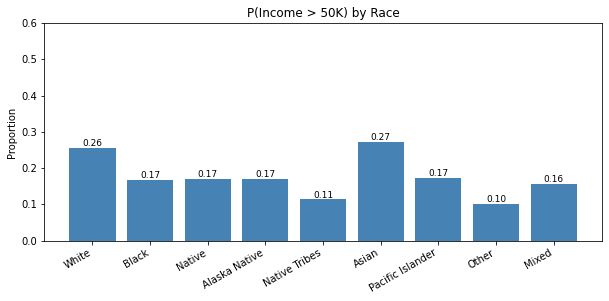

In [7]:
# Base rates by RAC1P
race_labels = {
    1: 'White', 2: 'Black', 3: 'Native', 4: 'Alaska Native',
    5: 'Native Tribes', 6: 'Asian', 7: 'Pacific Islander', 8: 'Other', 9: 'Mixed'
}
race_base = df.groupby('RAC1P')['label'].mean().rename(race_labels)

plt.figure(figsize=(10, 4))
bars = plt.bar(race_base.index, race_base.values, color='steelblue')
plt.title('P(Income > 50K) by Race')
plt.ylabel('Proportion')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 0.6)
for bar, val in zip(bars, race_base.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.2f}', ha='center', fontsize=9)
plt.show()

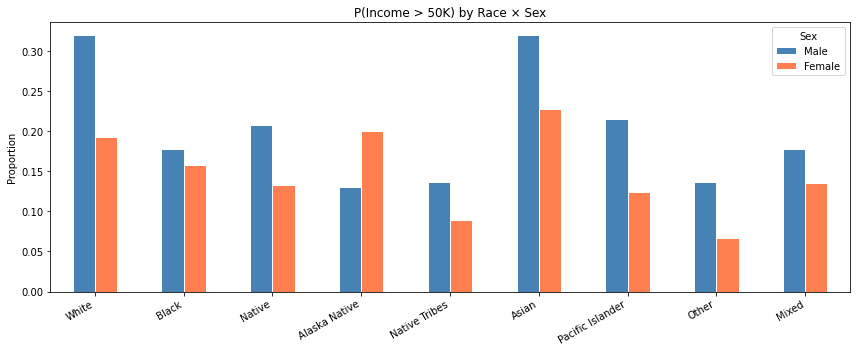

                   Male  Female  Gap (M-F)
RAC1P                                     
White             0.320   0.192      0.128
Black             0.178   0.158      0.019
Native            0.208   0.133      0.075
Alaska Native     0.130   0.200     -0.070
Native Tribes     0.137   0.089      0.048
Asian             0.320   0.228      0.092
Pacific Islander  0.216   0.125      0.091
Other             0.136   0.067      0.070
Mixed             0.178   0.135      0.043


In [8]:
# Intersectional base rates: SEX x RAC1P
intersect = df.groupby(['RAC1P', 'SEX'])['label'].mean().unstack()
intersect.index = intersect.index.map(race_labels)
intersect.columns = ['Male', 'Female']

intersect.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'coral'], edgecolor='white')
plt.title('P(Income > 50K) by Race × Sex')
plt.ylabel('Proportion')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

# gap within each racial group
intersect['Gap (M-F)'] = intersect['Male'] - intersect['Female']
print(intersect.round(3))

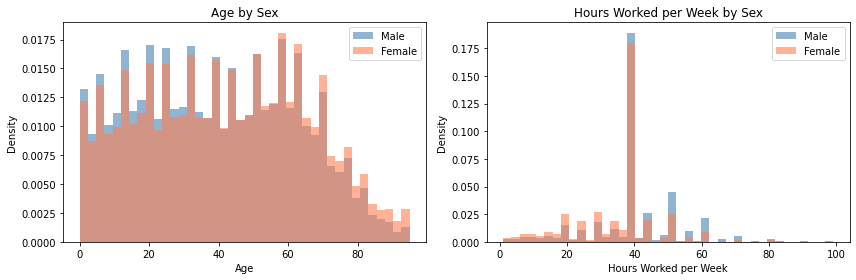

In [9]:
# Continuous feature distributions split by SEX
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes, ['AGEP', 'WKHP'], ['Age', 'Hours Worked per Week']):
    for sex, label, color in [(0, 'Male', 'steelblue'), (1, 'Female', 'coral')]:
        ax.hist(df[df['SEX'] == sex][col], bins=40, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(f'{title} by Sex')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

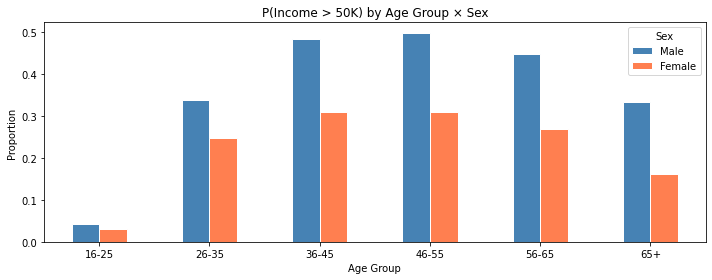

In [10]:
# Income rate by age group and sex
df['age_group'] = pd.cut(df['AGEP'], bins=[15, 25, 35, 45, 55, 65, 100],
                          labels=['16-25', '26-35', '36-45', '46-55', '56-65', '65+'])

age_sex = df.groupby(['age_group', 'SEX'])['label'].mean().unstack()
age_sex.columns = ['Male', 'Female']

age_sex.plot(kind='bar', figsize=(10, 4), color=['steelblue', 'coral'], edgecolor='white')
plt.title('P(Income > 50K) by Age Group × Sex')
plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

# Part 2: Preprocessing
### Missing values

In [11]:

# Check missing originally
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# work from copy from now on + drop nans
df_clean = df.copy()
df_clean = df_clean.dropna()
print(f"\nOriginal size: {len(df)} | After dropping NaNs: {len(df_clean)}")

Missing values per column:
AGEP              0
COW          347883
SCHL          25433
MAR               0
OCCP         347883
POBP              0
RELP              0
WKHP         406573
SEX               0
RAC1P             0
label             0
age_group    154570
dtype: int64

Total missing: 1282342

Original size: 843884 | After dropping NaNs: 437311


### Define feature groups

In [12]:
continuous_features  = ['AGEP', 'WKHP']
protected_attributes = ['SEX', 'RAC1P']   # kept separate for fairness eval
categorical_features = [col for col in df.columns
                        if col not in continuous_features + protected_attributes + ['label', 'age_group']]

print("Continuous: ", continuous_features)

print("Categorical:", categorical_features)
print("Protected:  ", protected_attributes)

Continuous:  ['AGEP', 'WKHP']
Categorical: ['COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP']
Protected:   ['SEX', 'RAC1P']


### Train test split (before encoding to avoid leakage)

In [13]:
X = df_clean.drop(columns=['label', 'age_group'], errors='ignore')
y = df_clean['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.3f} | Test positive rate: {y_test.mean():.3f}")

# Save protected attributes separately for fairness evaluation later
sex_test  = X_test['SEX'].values
race_test = X_test['RAC1P'].values

Train size: 349848 | Test size: 87463
Train positive rate: 0.395 | Test positive rate: 0.395


### Build preprocessing pipeline

In [14]:
# Keep SEX and RAC1P as passthrough (not transformed)
# so we can easily include/exclude them in model configurations


preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), continuous_features),
    ('ohe',   OneHotEncoder(sparse_output = False, handle_unknown='ignore'), categorical_features),
    ('protect', 'passthrough', protected_attributes)  # keep as-is
])

# Fit on train, transform both
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Recover feature names for readability
ohe_feature_names = preprocessor.named_transformers_['ohe'].get_feature_names_out(categorical_features)
all_feature_names = continuous_features + list(ohe_feature_names) + protected_attributes

X_train_df = pd.DataFrame(X_train_proc, columns=all_feature_names)
X_test_df  = pd.DataFrame(X_test_proc,  columns=all_feature_names)


print(f"Processed feature matrix shape: {X_train_df.shape}")
print(X_train_df.head(2))

Processed feature matrix shape: (349848, 811)
       AGEP      WKHP  COW_1.0  COW_2.0  COW_3.0  COW_4.0  COW_5.0  COW_6.0  \
0 -0.054605 -0.171307      1.0      0.0      0.0      0.0      0.0      0.0   
1 -1.444200 -0.778169      1.0      0.0      0.0      0.0      0.0      0.0   

   COW_7.0  COW_8.0  ...  RELP_10  RELP_11  RELP_12  RELP_13  RELP_14  \
0      0.0      0.0  ...      0.0      1.0      0.0      0.0      0.0   
1      0.0      0.0  ...      0.0      0.0      1.0      0.0      0.0   

   RELP_15  RELP_16  RELP_17  SEX  RAC1P  
0      0.0      0.0      0.0  1.0    2.0  
1      0.0      0.0      0.0  1.0    8.0  

[2 rows x 811 columns]


### Performance check function

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd

def evaluate_performance(y_test, y_pred, X_test):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    group_F = (X_test['SEX'] == 0)
    group_M = (X_test['SEX'] == 1)

    # SPD on favourable outcome (y_pred == 0), favoured - disadvantaged
    prob_fav_M  = (y_pred[group_M]  == 0).mean()
    prob_fav_F = (y_pred[group_F] == 0).mean()
    spd = prob_fav_M - prob_fav_F

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Statistical Parity Difference:", spd)

### Full Dataset

In [16]:
from sklearn.linear_model import LogisticRegression

logreg1 = LogisticRegression(random_state=67, max_iter=1000)
logreg1.fit(X_train_df, y_train)

y_pred1 = logreg1.predict(X_test_df)

evaluate_performance(y_test,y_pred1,X_test_df)

Accuracy: 0.811657500886089
Precision: 0.7690474062155478
Recall: 0.7474226804123711
F1 Score: 0.7580808600002937
Statistical Parity Difference: 0.14668051275622762


### Without Sensitive attribute (Sex)

In [17]:
logreg2 = LogisticRegression(random_state=67, max_iter=1000)
logreg2.fit(X_train_df.drop(columns=['SEX']), y_train)

y_pred2 = logreg2.predict(X_test_df.drop(columns=['SEX']))

evaluate_performance(y_test,y_pred2,X_test_df)

Accuracy: 0.80987388953043
Precision: 0.7656310276269326
Recall: 0.747162052588903
F1 Score: 0.7562838006184871
Statistical Parity Difference: 0.09225496074866912


### Without Proxies (MAR and RELP)

In [33]:
proxies = ["MAR_1", "MAR_2", "MAR_3", "MAR_4", "MAR_5","RELP_0", "RELP_1", "RELP_2", 
           "RELP_3", "RELP_4", "RELP_5", "RELP_6", "RELP_7", "RELP_8", "RELP_9",
           "RELP_10", "RELP_11","RELP_12","RELP_13","RELP_14","RELP_15", "RELP_16","RELP_17"]

logreg3 = LogisticRegression(random_state=67, max_iter=1000)
logreg3.fit(X_train_df.drop(columns=proxies), y_train)

y_pred3 = logreg3.predict(X_test_df.drop(columns=proxies))

evaluate_performance(y_test,y_pred3,X_test_df)

Accuracy: 0.806295233412986
Precision: 0.7643999518999519
Recall: 0.7363315185914514
F1 Score: 0.7501032509292584
Statistical Parity Difference: 0.1453800211772922
